In [55]:
import matplotlib.pyplot as plt

In [56]:
# Sequence Data
Sequence1 = "LGASGIAAFAFGSTAILIILFNMAAEVHFDPLQFFRQFFWLGLYPPKAQY"
seq_str_1 = "XHHHHHHHHHHHHHHHHHHHHHHHHHXXXXXXXXXXXXXXXXXXXXXXXX"

Sequence2 = "GMGIPPLHDGGWWLMAGLFMTLSLGSWWIRVYSRARALGLGTHIAWNFAA"
seq_str_2 = "XXXXXXXXXXHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHXXHHHHHHHH"

Sequence3 = "AIFFVLCIGCIHPTLVGSWSEGVPFGIWPHIDWLTAFSIRYGNFYYCPWH"
seq_str_3 = "HHHHHHHHHXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXHHH"

Sequence4 = "GFSIGFAYGCGLLFAAHGATILAVARFGGDREIEQITDRGTAVERAALFW"
seq_str_4 = "HHHHHHHHHHHHHHHHHHHHHHHXXXXXXXXXXXXXXXXXXXXXXXXXXX"

seq_total = Sequence1 + Sequence2 + Sequence3 + Sequence4
seq_str_total = seq_str_1 + seq_str_2 + seq_str_3 + seq_str_4

In [57]:
# Question 1
def propensity_alpha(seq, seq_str):
  count_alpha = 0
  propensity_scores, occurence_helix, occurence = {}, {}, {}

  AAs = "ACDEFGHIKLMNPQRSTVWY"
  total_helix = seq_str.count("H")

  for AA in AAs:
    propensity_scores[AA] = 0
    occurence[AA] = seq.count(AA)
    occurence_helix[AA] = 0

  for n in range(len(seq)):
    if seq_str[n] == "H":
      occurence_helix[seq[n]] += 1

  for AA in propensity_scores.keys():
    AA_in_helix = occurence_helix[AA]/occurence[AA]
    Res_in_helix = total_helix/len(seq)

    propensity_scores[AA] = round((AA_in_helix/Res_in_helix),3)

  for AA in propensity_scores.keys():
    print(f"Score of {AA}: {propensity_scores[AA]}")

In [58]:
propensity_alpha(seq_total , seq_str_total)

Score of A: 1.551
Score of C: 1.02
Score of D: 0.0
Score of E: 0.408
Score of F: 1.02
Score of G: 1.061
Score of H: 0.875
Score of I: 1.2
Score of K: 0.0
Score of L: 1.224
Score of M: 1.531
Score of N: 1.361
Score of P: 0.227
Score of Q: 0.0
Score of R: 0.68
Score of S: 1.361
Score of T: 0.765
Score of V: 0.583
Score of W: 1.113
Score of Y: 0.583


In [59]:
# Question 3
# Chou fasman propensity data

chou_fasman_alpha = {
    "E": 1.53,
    "A": 1.45,
    "L": 1.34,
    "H": 1.24,
    "M": 1.20,
    "Q": 1.17,
    "W": 1.14,
    "V": 1.14,
    "F": 1.12,
    "K": 1.07,
    "I": 1.00,
    "D": 0.98,
    "T": 0.82,
    "S": 0.79,
    "R": 0.79,
    "C": 0.77,
    "N": 0.73,
    "Y": 0.61,
    "P": 0.59,
    "G": 0.53
}

chou_fasman_beta = {
    "M": 1.67,
    "V": 1.65,
    "I": 1.60,
    "C": 1.30,
    "Y": 1.29,
    "F": 1.28,
    "Q": 1.23,
    "L": 1.22,
    "T": 1.20,
    "W": 1.19,
    "A": 0.97,
    "R": 0.90,
    "G": 0.81,
    "D": 0.80,
    "K": 0.74,
    "S": 0.72,
    "H": 0.71,
    "N": 0.65,
    "P": 0.62,
    "E": 0.26
}

In [60]:
# Intial checking conditions
helix_dict = {
    "E": 1,    # Hα
    "A": 1,    # Hα
    "L": 1,    # Hα

    "H": 1,    # hα
    "M": 1,    # hα
    "Q": 1,    # hα
    "W": 1,    # hα
    "V": 1,    # hα
    "F": 1,    # hα

    "K": 0.5,  # Iα
    "I": 0.5,  # Iα

    "D": 0,    # iα
    "T": 0,    # iα
    "S": 0,    # iα
    "R": 0,    # iα
    "C": 0,    # iα

    "N": -1,   # bα
    "Y": -1,   # bα

    "P": -1,   # Bα
    "G": -1    # Bα
}

strand_dict = {
    "M": 1,    # Hβ
    "V": 1,    # Hβ
    "I": 1,    # Hβ

    "C": 1,    # hβ
    "Y": 1,    # hβ
    "F": 1,    # hβ
    "Q": 1,    # hβ
    "L": 1,    # hβ
    "T": 1,    # hβ
    "W": 1,    # hβ

    "A": 0.5,  # Iβ

    "R": 0,    # iβ
    "G": 0,    # iβ
    "D": 0,    # iβ

    "K": -1,   # bβ
    "S": -1,   # bβ
    "H": -1,   # bβ
    "N": -1,   # bβ
    "P": -1,   # bβ

    "E": -1    # Bβ
}

In [61]:
def helix_identification(seq):
  helix_regions = set()
  window_size = 6
  second_window = 4

  for n in range(len(seq) - window_size + 1):
    count = 0

    # Checking for the seed region
    cur = seq[n : n + window_size]
    cur_score = sum(helix_dict[AA] for AA in cur)

    # If appropriate seed region
    if cur_score >= 4:

      # Extend if possble
      if n + window_size < len(seq):
        count += 1
        cur = seq[n : n + window_size + count]

      # Breakout if extension is not possible
      else:
        helix_regions.update(set(range(n, n + window_size)))
        break

      # Using a flag for extension
      flag = True

      while flag:
        checker = sum(chou_fasman_alpha[AA] for AA in cur[-second_window:])

        # Terminate extension if either low score or end of the sequences is reached
        if checker < 4 :
          flag = False
          helix_regions.update(set(range(n, n + window_size + count - 1)))

        elif checker >= 4  and (n + window_size + count) >= len(seq):
          flag = False
          helix_regions.update(set(range(n, n + window_size + count)))

        # If no issues, continue extending
        else:
          count += 1
          cur = seq[n : n + window_size + count]

  contiguous_blocks, block, block_no = {}, False, 1
  start = None
  n = 0
  while n < (len(seq)):

    if (n in helix_regions) and (block == False):
      start, block = n, True

    elif (n not in helix_regions) and (block == True):
      contiguous_blocks[block_no]  = (seq[start:n], (start, n-1))
      block_no += 1
      block, start =  False, None

    elif (n == (len(seq)-1)) and (block == True):
      contiguous_blocks[block_no]  = (seq[start:], (start, n))
      block_no += 1
      block, start =  False, None

    n+=1

  for ID in contiguous_blocks.keys():
    avg_propensity_score = (sum(chou_fasman_alpha[AA] for AA in contiguous_blocks[ID][0]))/len(contiguous_blocks[ID][0])
    print(f"The sequence {contiguous_blocks[ID][0]}, ranging from {contiguous_blocks[ID][1]}, is identified as a alpha-helix. Propensity score : {avg_propensity_score}")

  return(helix_regions)

In [62]:
sequence = "KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL"

helix_regions = helix_identification(sequence)

The sequence RCELAAAMKRH, ranging from (4, 14), is identified as a alpha-helix. Propensity score : 1.1890909090909092
The sequence WVCAAKFESNF, ranging from (27, 37), is identified as a alpha-helix. Propensity score : 1.1190909090909091
The sequence MNAWVAWRN, ranging from (104, 112), is identified as a alpha-helix. Propensity score : 1.0855555555555556
The sequence TDVQAWIR, ranging from (117, 124), is identified as a alpha-helix. Propensity score : 1.06125


In [63]:
def strand_identification(seq):
  strand_regions = set()
  window_size = 5
  second_window = 3

  for n in range(len(seq) - window_size + 1):
    count = 0

    # Checking for the seed region
    cur = seq[n : n + window_size]
    cur_score = sum(strand_dict[AA] for AA in cur)

    # If appropriate seed region
    if cur_score >= 3:

      # Extend if possble
      if n + window_size < len(seq):
        count += 1
        cur = seq[n : n + window_size + count]

      # Breakout if extension is not possible
      else:
        strand_regions.update(set(range(n, n + window_size)))
        break

      # Using a flag for extension
      flag = True

      while flag:
        checker = sum(chou_fasman_beta[AA] for AA in cur[-second_window:])

        # Terminate extension if either low score or end of the sequences is reached
        if checker < 3 :
          flag = False
          strand_regions.update(set(range(n, n + window_size + count - 1)))

        elif checker >= 3  and (n + window_size + count) >= len(seq):
          flag = False
          strand_regions.update(set(range(n, n + window_size + count)))

        # If no issues, continue extending
        else:
          count += 1
          cur = seq[n : n + window_size + count]

  contiguous_blocks, block, block_no = {}, False, 1
  start = None
  n = 0
  while n < (len(seq)):

    if (n in strand_regions) and (block == False):
      start, block = n, True

    elif (n not in strand_regions) and (block == True):
      contiguous_blocks[block_no]  = (seq[start:n], (start, n-1))
      block_no += 1
      block, start =  False, None

    elif (n == (len(seq)-1)) and (block == True):
      contiguous_blocks[block_no]  = (seq[start:], (start, n))
      block_no += 1
      block, start =  False, None

    n+=1

  for ID in contiguous_blocks.keys():
    avg_propensity_score = (sum(chou_fasman_alpha[AA] for AA in contiguous_blocks[ID][0]))/len(contiguous_blocks[ID][0])
    print(f"The sequence {contiguous_blocks[ID][0]}, ranging from {contiguous_blocks[ID][1]}, is identified as a beta-strand. Propensity score : {avg_propensity_score}")

  return(strand_regions)

In [64]:
sequence = "KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL"

strand_regions = strand_identification(sequence)

The sequence VFGRC, ranging from (1, 5), is identified as a beta-strand. Propensity score : 0.8699999999999999
The sequence LAAAMKR, ranging from (7, 13), is identified as a beta-strand. Propensity score : 1.25
The sequence WVCAA, ranging from (27, 31), is identified as a beta-strand. Propensity score : 1.19
The sequence TDYGILQIN, ranging from (50, 58), is identified as a beta-strand. Propensity score : 0.9088888888888889
The sequence AWVAWR, ranging from (106, 111), is identified as a beta-strand. Propensity score : 1.1849999999999998
The sequence GTDVQAWIRGCRL, ranging from (116, 128), is identified as a beta-strand. Propensity score : 0.9576923076923076


In [65]:
helix_spots = [(4, 14), (27, 37), (104, 112), (117, 124)]
strand_spots = [(1, 5), (7, 13), (27, 31), (50, 58), (106, 111), (116, 128)]

seq_len = len(sequence)

In [66]:
def to_blocks(intervals):
    return [(start, end - start + 1) for start, end in intervals]

helix_blocks = to_blocks(helix_spots)
strand_blocks = to_blocks(strand_spots)

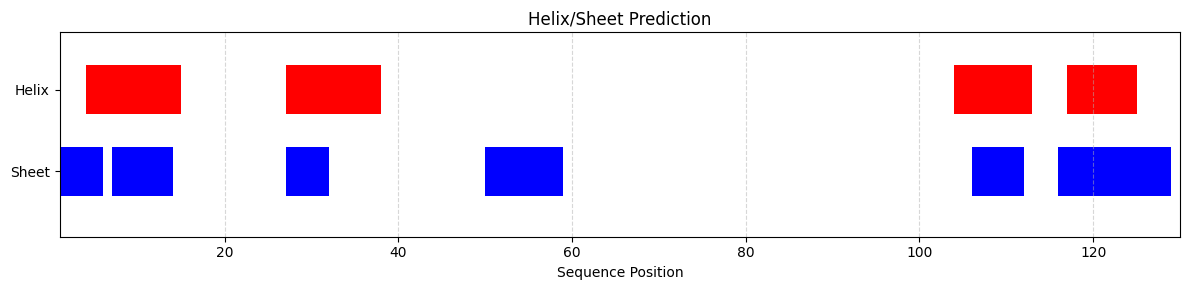

In [67]:
# Plot
fig, ax = plt.subplots(figsize=(12, 3))

# Draw bars
ax.broken_barh(helix_blocks, (30, 6), facecolors='red')
ax.broken_barh(strand_blocks, (20, 6), facecolors='blue')

# Labels
ax.set_yticks([33, 23])
ax.set_yticklabels(['Helix', 'Sheet'])

ax.set_xlim(1, seq_len + 1)
ax.set_ylim(15, 40)

ax.set_xlabel("Sequence Position")
ax.set_title("Helix/Sheet Prediction")

ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [68]:
overlap = list(strand_regions.intersection(helix_regions))

contiguous_blocks, block, block_no = {}, False, 1
start = None
n = 0

while n < (len(overlap)):

  if block == False:
    start, block = overlap[n], True

  elif (n == (len(overlap)-1)) and (block == True):
    contiguous_blocks[block_no]  = list(range(start, overlap[n]+1))
    block_no += 1
    block, start =  False, None

  elif (overlap[n]+1) not in overlap:
    contiguous_blocks[block_no]  = list(range(start, overlap[n]+1))
    block_no += 1
    block, start =  False, None
  n+=1

overlaps = []
for ID in contiguous_blocks.keys():
    print(f"The segment {contiguous_blocks[ID]} overlaps")
    overlaps.append(contiguous_blocks[ID])

The segment [4, 5] overlaps
The segment [7, 8, 9, 10, 11, 12, 13] overlaps
The segment [27, 28, 29, 30, 31] overlaps
The segment [106, 107, 108, 109, 110, 111] overlaps
The segment [117, 118, 119, 120, 121, 122, 123, 124] overlaps


In [69]:
def check_overlaps(overlaps, seq):
  alphas, betas = [], []
  for overlap in overlaps:
    temp_seq = seq[overlap[0]:(overlap[-1]+1)]
    alpha_score = sum(chou_fasman_alpha[AA] for AA in temp_seq)
    beta_score = sum(chou_fasman_beta[AA] for AA in temp_seq)

    if alpha_score > beta_score:
      alphas.append(overlap)
    else:
      betas.append(overlap)

  return(alphas,betas)

In [70]:
op = check_overlaps(overlaps, sequence)
print(f"The regions of overlapping alpha-helices:")
for alpha in op[0]:
  print(alpha)
print("="*125)
print(f"The regions of overlapping beta-strands:")
for beta in op[1]:
  print(beta)
print("="*125)

The regions of overlapping alpha-helices:
[7, 8, 9, 10, 11, 12, 13]
[106, 107, 108, 109, 110, 111]
The regions of overlapping beta-strands:
[4, 5]
[27, 28, 29, 30, 31]
[117, 118, 119, 120, 121, 122, 123, 124]


In [71]:
# Resolving using the propensity scores for the overlapped regions
helix_final = [(6, 14), (32, 37), (104, 112)]
strand_final = [(1, 5) , (27, 31), (50, 58), (116, 128)]

helix_final_blocks = to_blocks(helix_final)
strand_final_blocks = to_blocks(strand_final)

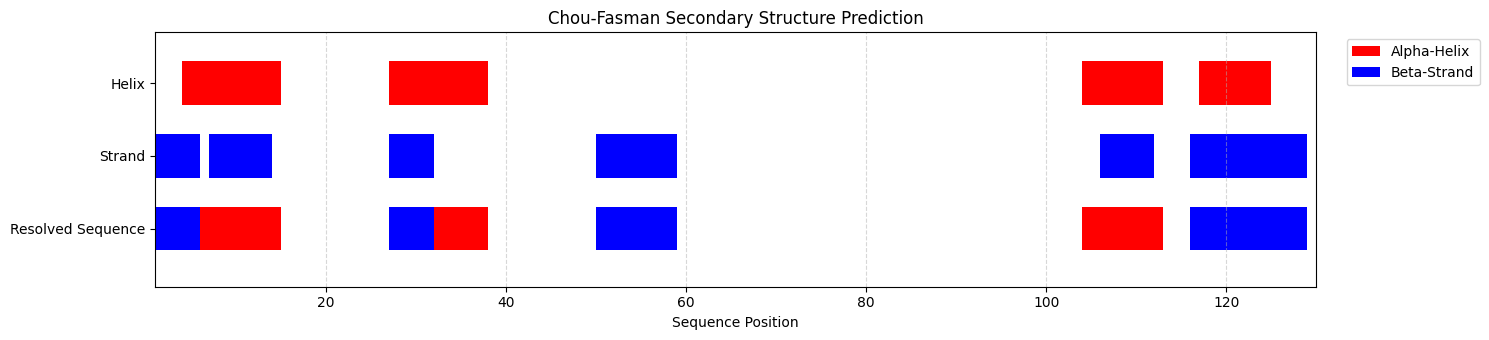

In [72]:
# Plot
fig, ax = plt.subplots(figsize=(15, 3.5))

# Top row: original helix
ax.broken_barh(helix_blocks, (30, 6), facecolors='red', label='Helix')

# Middle row: original strand
ax.broken_barh(strand_blocks, (20, 6), facecolors='blue', label='Strand')

# Bottom row: resolved final sequence
ax.broken_barh(helix_final_blocks, (10, 6), facecolors='red')
ax.broken_barh(strand_final_blocks, (10, 6), facecolors='blue')

# Labels
ax.set_yticks([33, 23, 13])
ax.set_yticklabels(['Helix', 'Strand', 'Resolved Sequence'])

ax.set_xlim(1, seq_len + 1)
ax.set_ylim(5, 40)

ax.set_xlabel("Sequence Position")
ax.set_title("Chou-Fasman Secondary Structure Prediction")

ax.grid(axis='x', linestyle='--', alpha=0.5)

# Optional legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='red', label='Alpha-Helix'),
    Patch(facecolor='blue', label='Beta-Strand')
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()